# 07 P-value Comparison - Centrality vs Embeddings

Compare saved test metrics from the centrality-measure approach and the embedding approach across p-values.

This notebook does not retrain models. It reads the saved metrics from notebooks 04b and 05d.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'requirements.txt').exists():
            return path
    raise FileNotFoundError('Project root not found.')


PROJECT_ROOT = find_project_root()

CENTRALITY_METRICS_PATH = PROJECT_ROOT / 'src' / 'data' / 'predictions' / '04b_saved_04a' / 'metrics.csv'
EMBEDDING_METRICS_PATH = PROJECT_ROOT / 'src' / 'data' / 'predictions' / '05d_saved_05a' / 'metrics.csv'
OUT_DIR = PROJECT_ROOT / 'src' / 'data' / 'predictions' / '07_p_value_comparison'
OUT_DIR.mkdir(parents=True, exist_ok=True)

P_ORDER = ['p0', 'p5', 'p10', 'p15', 'p20', 'p25', 'p30', 'p35', 'p40']
DATASET_P_ORDER = {
    'dataset1': P_ORDER,
    'dataset2': P_ORDER,
}
P_RANK = {p: i for i, p in enumerate(P_ORDER)}
ROUND_DECIMALS = 3

REQUIRED_COLS = [
    'dataset', 'experiment', 'test_rmse', 'test_mae',
    'test_top1_rmse', 'test_top1_mae',
]

pd.set_option('display.max_columns', 120)
print(PROJECT_ROOT)

C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis


## Load and clean saved metrics

In [10]:
def load_metrics(path, approach):
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path)
    missing = [col for col in REQUIRED_COLS if col not in df.columns]
    if missing:
        raise ValueError(f'{path.name} missing required columns: {missing}')

    df = df.copy()
    df['approach'] = approach
    return df


centrality = load_metrics(CENTRALITY_METRICS_PATH, 'Centrality')
embeddings = load_metrics(EMBEDDING_METRICS_PATH, 'Embeddings')

combined = pd.concat([centrality, embeddings], ignore_index=True, sort=False)
combined['dataset_group'] = combined['dataset'].str.extract(r'^(dataset[12])')[0]
combined['p_value'] = combined['dataset'].str.extract(r'_(p\d+)$')[0]
combined.loc[combined['dataset'].str.endswith('_baseline'), 'p_value'] = 'p0'
combined['p_num'] = combined['p_value'].map(P_RANK)

keep = (
    ((combined['dataset_group'] == 'dataset1') & (combined['approach'] == 'Centrality') & (combined['experiment'] == 'dataset1_temporal_train_04a_specs')) |
    ((combined['dataset_group'] == 'dataset1') & (combined['approach'] == 'Embeddings') & (combined['experiment'] == 'dataset1_temporal_train_05a_specs')) |
    ((combined['dataset_group'] == 'dataset2') & (combined['approach'] == 'Centrality') & (combined['experiment'] == 'dataset2_random_train_04a_specs')) |
    ((combined['dataset_group'] == 'dataset2') & (combined['approach'] == 'Embeddings') & (combined['experiment'] == 'dataset2_random_train_05a_specs'))
)

comparison = combined.loc[keep].copy()
comparison = comparison[
    comparison.apply(
        lambda row: row['p_value'] in DATASET_P_ORDER[row['dataset_group']],
        axis=1,
    )
].copy()
comparison = comparison.sort_values(['dataset_group', 'approach', 'p_num']).reset_index(drop=True)
metric_cols = [col for col in comparison.columns if any(name in col for name in ['rmse', 'mae', 'r2'])]
comparison[metric_cols] = comparison[metric_cols].round(ROUND_DECIMALS)

for dataset_group in ['dataset1', 'dataset2']:
    for approach in ['Centrality', 'Embeddings']:
        got = comparison.loc[
            (comparison['dataset_group'] == dataset_group) &
            (comparison['approach'] == approach),
            'p_value'
        ].tolist()
        expected = DATASET_P_ORDER[dataset_group]
        if got != expected:
            raise ValueError(f'{dataset_group} {approach} has p-values {got}, expected {expected}')

combined_path = OUT_DIR / 'combined_metrics.csv'
comparison.to_csv(combined_path, index=False)

print(f'Saved combined metrics: {combined_path}')
display(comparison[['approach', 'dataset_group', 'p_value', 'experiment', 'model', 'test_rmse', 'test_mae', 'test_top1_rmse', 'test_top1_mae']])

Saved combined metrics: C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\predictions\07_p_value_comparison\combined_metrics.csv


,approach,dataset_group,p_value,experiment,model,test_rmse,test_mae,test_top1_rmse,test_top1_mae
0,Centrality,dataset1,p0,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.070,0.012,0.451,0.366
1,Centrality,dataset1,p5,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.069,0.012,0.431,0.351
2,Centrality,dataset1,p10,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.070,0.013,0.439,0.359
3,Centrality,dataset1,p15,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.071,0.013,0.445,0.360
4,Centrality,dataset1,p20,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.070,0.013,0.426,0.349
5,Centrality,dataset1,p25,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.070,0.013,0.413,0.340
6,Centrality,dataset1,p30,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.071,0.014,0.383,0.313
7,Centrality,dataset1,p35,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.073,0.014,0.398,0.326
8,Centrality,dataset1,p40,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.074,0.015,0.379,0.308
9,Embeddings,dataset1,p0,dataset1_temporal_train_05a_specs,MLP (tuned),0.123,0.026,0.910,0.737


## Plot helpers

In [11]:
METRIC_PANELS = [
    ('test_rmse', 'Test RMSE'),
    ('test_mae', 'Test MAE'),
    ('test_top1_rmse', 'Top 1% test RMSE'),
    ('test_top1_mae', 'Top 1% test MAE'),
]

APPROACH_COLORS = {
    'Centrality': '#2ca02c',
    'Embeddings': '#1f77b4',
}


def build_summary_table(dataset_df):
    centrality = dataset_df[dataset_df['approach'] == 'Centrality'].set_index('p_value')
    embeddings = dataset_df[dataset_df['approach'] == 'Embeddings'].set_index('p_value')

    dataset_group = dataset_df['dataset_group'].iloc[0]
    include_top1 = dataset_group == 'dataset1'

    rows = []
    p_order = DATASET_P_ORDER[dataset_group]
    for p_value in p_order:
        c = centrality.loc[p_value]
        e = embeddings.loc[p_value]
        row = {
            'p_value': p_value,
            'centrality_test_rmse': c['test_rmse'],
            'embeddings_test_rmse': e['test_rmse'],
            'centrality_test_mae': c['test_mae'],
            'embeddings_test_mae': e['test_mae'],
            'winner_test_rmse': 'Centrality' if c['test_rmse'] <= e['test_rmse'] else 'Embeddings',
        }
        if include_top1:
            row.update({
                'centrality_top1_rmse': c['test_top1_rmse'],
                'embeddings_top1_rmse': e['test_top1_rmse'],
                'centrality_top1_mae': c['test_top1_mae'],
                'embeddings_top1_mae': e['test_top1_mae'],
                'winner_top1_rmse': 'Centrality' if c['test_top1_rmse'] <= e['test_top1_rmse'] else 'Embeddings',
            })
        rows.append(row)

    summary = pd.DataFrame(rows)
    numeric_cols = summary.select_dtypes(include='number').columns
    summary[numeric_cols] = summary[numeric_cols].round(ROUND_DECIMALS)
    return summary


def plot_dataset_comparison(comparison_df, dataset_group, title, output_filename):
    dataset_df = comparison_df[comparison_df['dataset_group'] == dataset_group].copy()
    dataset_df = dataset_df.sort_values('p_num')

    panels = METRIC_PANELS if dataset_group == 'dataset1' else [p for p in METRIC_PANELS if 'top1' not in p[0]]
    nrows, ncols = (2, 2) if len(panels) == 4 else (1, 2)

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows), sharex=True)
    axes = axes.ravel()

    for ax, (metric_col, metric_title) in zip(axes, panels):
        for approach in ['Centrality', 'Embeddings']:
            group = dataset_df[dataset_df['approach'] == approach].sort_values('p_num')
            ax.plot(
                group['p_value'],
                group[metric_col],
                marker='o',
                linewidth=2,
                label=approach,
                color=APPROACH_COLORS[approach],
            )
        ax.set_title(metric_title)
        ax.set_xlabel('p-value')
        ax.set_ylabel('Error')
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()

    output_path = OUT_DIR / output_filename
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Saved figure: {output_path}')
    summary = build_summary_table(dataset_df)
    display(summary)
    return summary

## Dataset 1 comparison

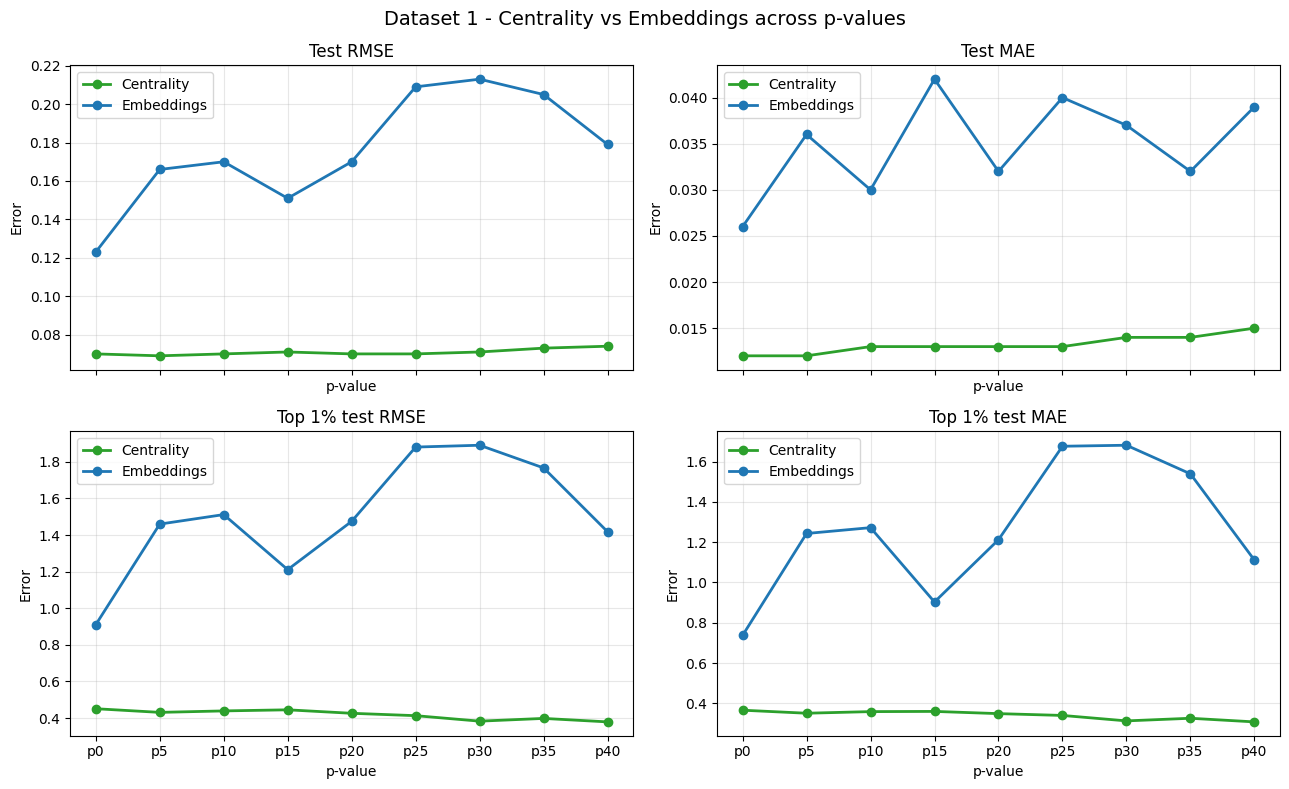

Saved figure: C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\predictions\07_p_value_comparison\dataset1_p_value_comparison.png


,p_value,centrality_test_rmse,embeddings_test_rmse,centrality_test_mae,embeddings_test_mae,winner_test_rmse,centrality_top1_rmse,embeddings_top1_rmse,centrality_top1_mae,embeddings_top1_mae,winner_top1_rmse
0,p0,0.070,0.123,0.012,0.026,Centrality,0.451,0.910,0.366,0.737,Centrality
1,p5,0.069,0.166,0.012,0.036,Centrality,0.431,1.460,0.351,1.243,Centrality
2,p10,0.070,0.170,0.013,0.030,Centrality,0.439,1.512,0.359,1.272,Centrality
3,p15,0.071,0.151,0.013,0.042,Centrality,0.445,1.211,0.360,0.903,Centrality
4,p20,0.070,0.170,0.013,0.032,Centrality,0.426,1.475,0.349,1.212,Centrality
5,p25,0.070,0.209,0.013,0.040,Centrality,0.413,1.881,0.340,1.676,Centrality
6,p30,0.071,0.213,0.014,0.037,Centrality,0.383,1.891,0.313,1.681,Centrality
7,p35,0.073,0.205,0.014,0.032,Centrality,0.398,1.767,0.326,1.539,Centrality
8,p40,0.074,0.179,0.015,0.039,Centrality,0.379,1.418,0.308,1.111,Centrality


In [12]:
dataset1_summary = plot_dataset_comparison(
    comparison,
    dataset_group='dataset1',
    title='Dataset 1 - Centrality vs Embeddings across p-values',
    output_filename='dataset1_p_value_comparison.png',
)

## Dataset 2 comparison

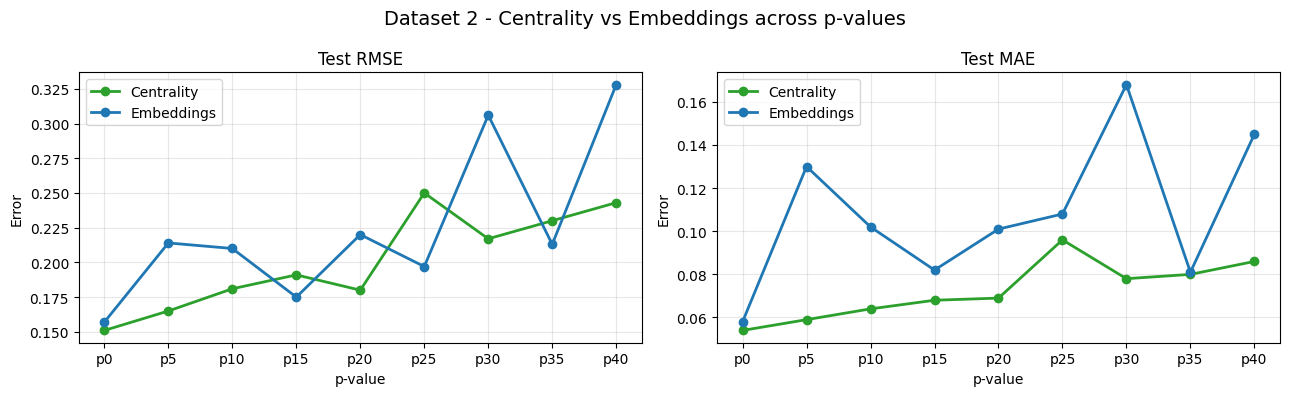

Saved figure: C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\predictions\07_p_value_comparison\dataset2_p_value_comparison.png


,p_value,centrality_test_rmse,embeddings_test_rmse,centrality_test_mae,embeddings_test_mae,winner_test_rmse
0,p0,0.151,0.157,0.054,0.058,Centrality
1,p5,0.165,0.214,0.059,0.130,Centrality
2,p10,0.181,0.210,0.064,0.102,Centrality
3,p15,0.191,0.175,0.068,0.082,Embeddings
4,p20,0.180,0.220,0.069,0.101,Centrality
5,p25,0.250,0.197,0.096,0.108,Embeddings
6,p30,0.217,0.306,0.078,0.168,Centrality
7,p35,0.230,0.213,0.080,0.081,Embeddings
8,p40,0.243,0.328,0.086,0.145,Centrality


In [13]:
dataset2_summary = plot_dataset_comparison(
    comparison,
    dataset_group='dataset2',
    title='Dataset 2 - Centrality vs Embeddings across p-values',
    output_filename='dataset2_p_value_comparison.png',
)

## Alternative grouped-bin visualizations

In [14]:
# Centrality = green family (dark → light), Embeddings = blue family (dark → light)
BAR_METRICS = [
    ('test_rmse',      'RMSE',        '#005a32', '#08306b'),
    ('test_mae',       'MAE',         '#238b45', '#2171b5'),
    ('test_top1_rmse', 'Top 1% RMSE', '#74c476', '#6baed6'),
    ('test_top1_mae',  'Top 1% MAE',  '#c7e9c0', '#c6dbef'),
]

LINE_COLOR_FAMILIES = {
    'Centrality': ['#005a32', '#238b45', '#74c476', '#c7e9c0'],
    'Embeddings': ['#08306b', '#2171b5', '#6baed6', '#c6dbef'],
}


def _bar_metrics_for(dataset_group):
    if dataset_group == 'dataset2':
        return [m for m in BAR_METRICS if 'top1' not in m[0]]
    return BAR_METRICS


def dataset_metric_series(comparison_df, dataset_group, approach, metric_col):
    data = comparison_df[
        (comparison_df['dataset_group'] == dataset_group) &
        (comparison_df['approach'] == approach)
    ].set_index('p_value').loc[DATASET_P_ORDER[dataset_group]]
    return data[metric_col].to_numpy()


def plot_grouped_bar_metrics(comparison_df, dataset_group, title, output_filename):
    p_order = DATASET_P_ORDER[dataset_group]
    x = np.arange(len(p_order))
    bar_metrics = _bar_metrics_for(dataset_group)
    n = len(bar_metrics)
    width = 0.8 / (n * 2)
    offset = -(2 * n - 1) / 2 * width

    fig, ax = plt.subplots(figsize=(15, 7))

    for metric_col, metric_label, centrality_color, embedding_color in bar_metrics:
        c_values = dataset_metric_series(comparison_df, dataset_group, 'Centrality', metric_col)
        e_values = dataset_metric_series(comparison_df, dataset_group, 'Embeddings', metric_col)

        ax.bar(x + offset, c_values, width, label=f'Centrality - {metric_label}', color=centrality_color)
        offset += width
        ax.bar(x + offset, e_values, width, label=f'Embeddings - {metric_label}', color=embedding_color)
        offset += width

    ax.set_title(title)
    ax.set_xlabel('p-value threshold (%)')
    ax.set_ylabel('Error value')
    ax.set_xticks(x)
    ax.set_xticklabels([p.replace('p', '') for p in p_order])
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(title='Approach & metric', bbox_to_anchor=(1.02, 1), loc='upper left')

    fig.tight_layout()
    output_path = OUT_DIR / output_filename
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved figure: {output_path}')


def plot_all_metric_lines(comparison_df, dataset_group, title, output_filename):
    p_order = DATASET_P_ORDER[dataset_group]
    x = np.array([int(p.replace('p', '')) for p in p_order])
    bar_metrics = _bar_metrics_for(dataset_group)

    fig, ax = plt.subplots(figsize=(13, 7))

    for i, (metric_col, metric_label, _, _) in enumerate(bar_metrics):
        centrality_color = LINE_COLOR_FAMILIES['Centrality'][i]
        embedding_color = LINE_COLOR_FAMILIES['Embeddings'][i]

        c_values = dataset_metric_series(comparison_df, dataset_group, 'Centrality', metric_col)
        e_values = dataset_metric_series(comparison_df, dataset_group, 'Embeddings', metric_col)

        ax.plot(x, c_values, marker='o', color=centrality_color, label=f'Centrality - {metric_label}')
        ax.plot(x, e_values, marker='s', linestyle='--', color=embedding_color, label=f'Embeddings - {metric_label}')

    ax.set_title(title)
    ax.set_xlabel('p-value threshold (%)')
    ax.set_ylabel('Error value')
    ax.set_xticks(x)
    ax.grid(True, alpha=0.3)
    ax.legend(title='Approach & metric', bbox_to_anchor=(1.02, 1), loc='upper left')

    fig.tight_layout()
    output_path = OUT_DIR / output_filename
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved figure: {output_path}')

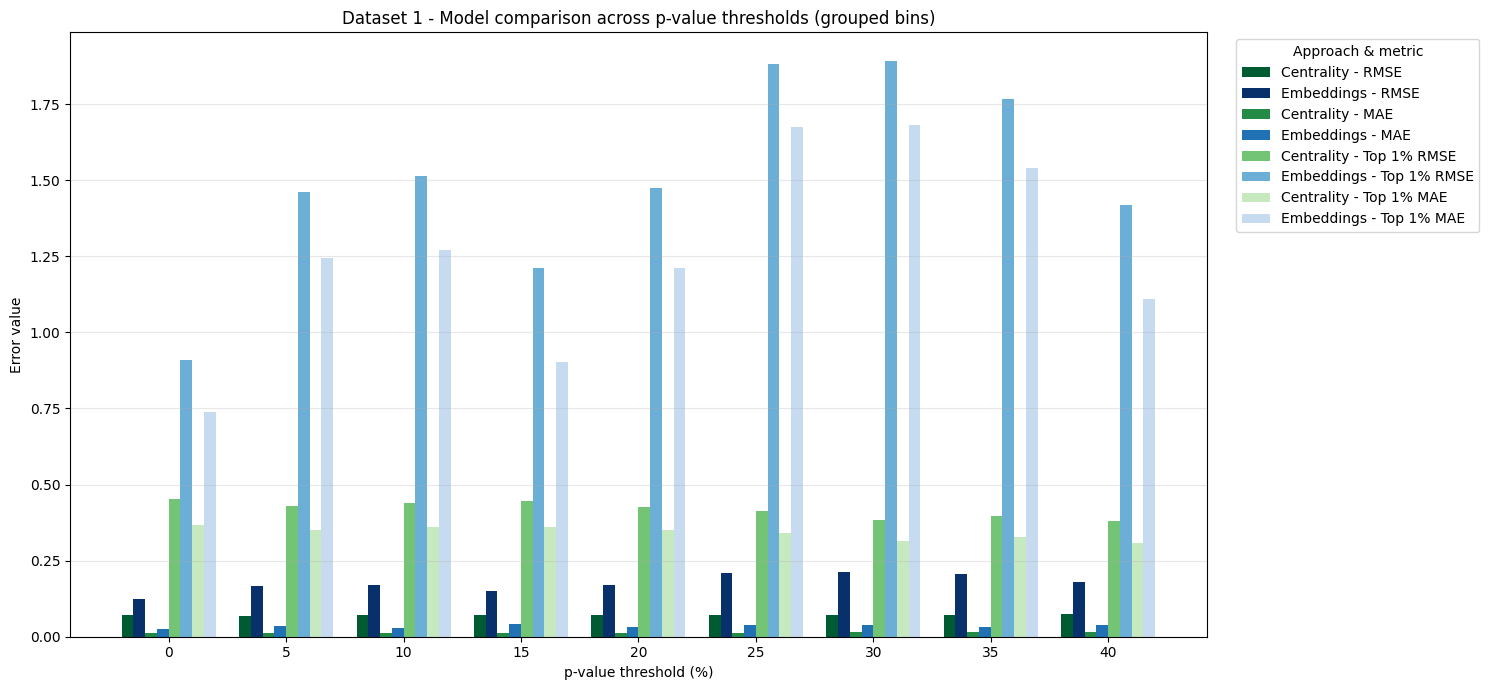

Saved figure: C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\predictions\07_p_value_comparison\dataset1_grouped_bins_all_metrics.png


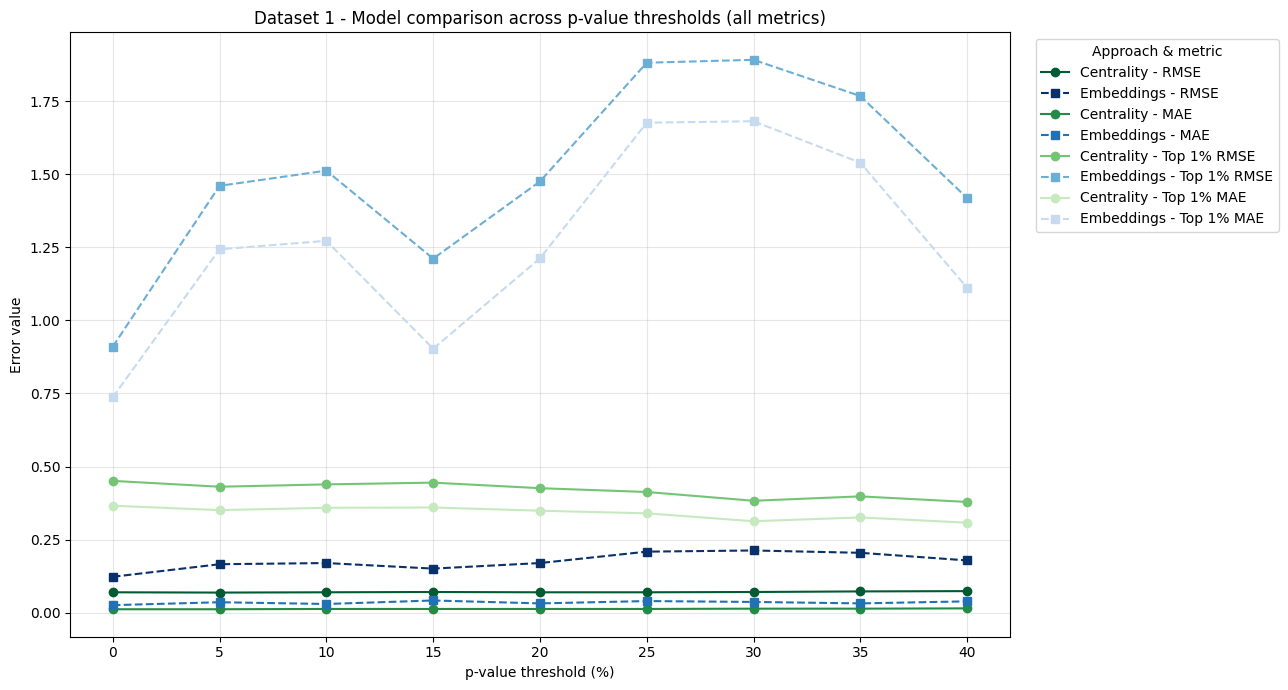

Saved figure: C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\predictions\07_p_value_comparison\dataset1_lines_all_metrics.png


In [15]:
plot_grouped_bar_metrics(
    comparison,
    dataset_group='dataset1',
    title='Dataset 1 - Model comparison across p-value thresholds (grouped bins)',
    output_filename='dataset1_grouped_bins_all_metrics.png',
)

plot_all_metric_lines(
    comparison,
    dataset_group='dataset1',
    title='Dataset 1 - Model comparison across p-value thresholds (all metrics)',
    output_filename='dataset1_lines_all_metrics.png',
)

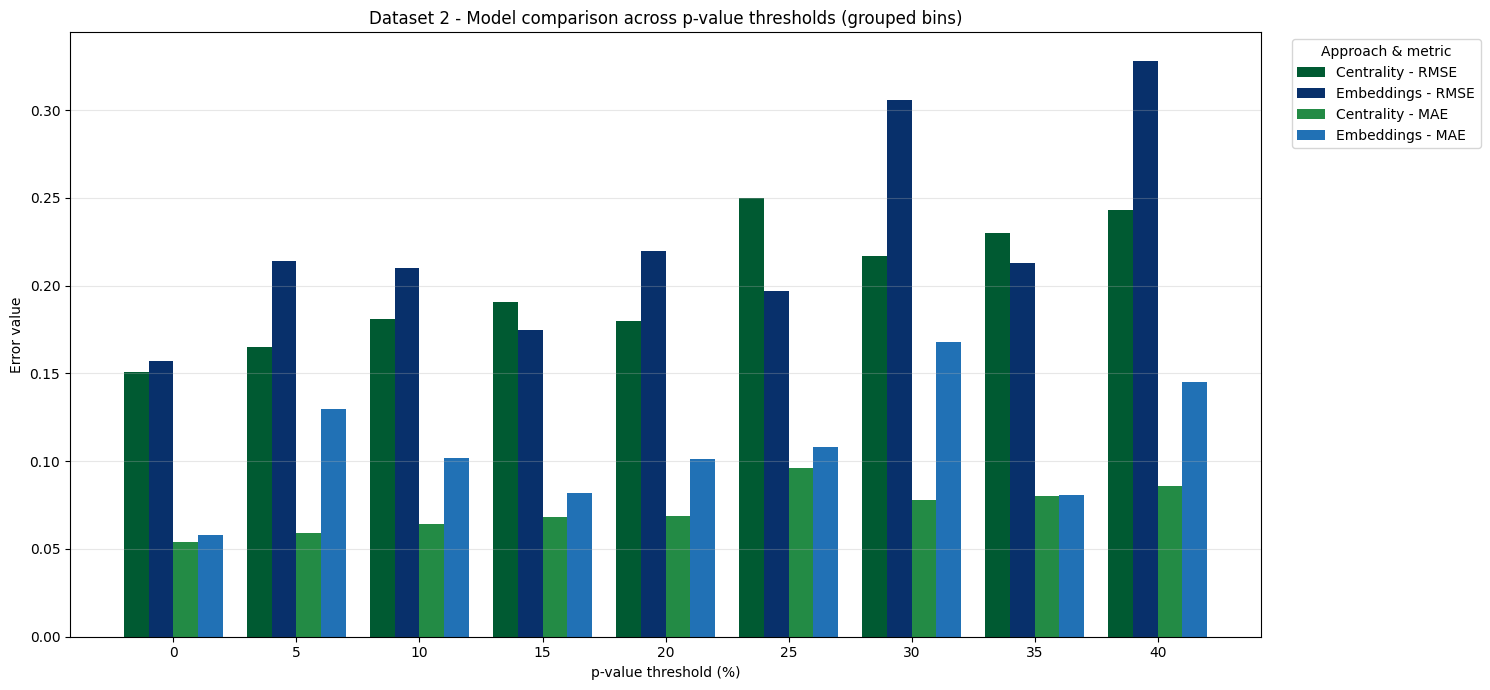

Saved figure: C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\predictions\07_p_value_comparison\dataset2_grouped_bins_all_metrics.png


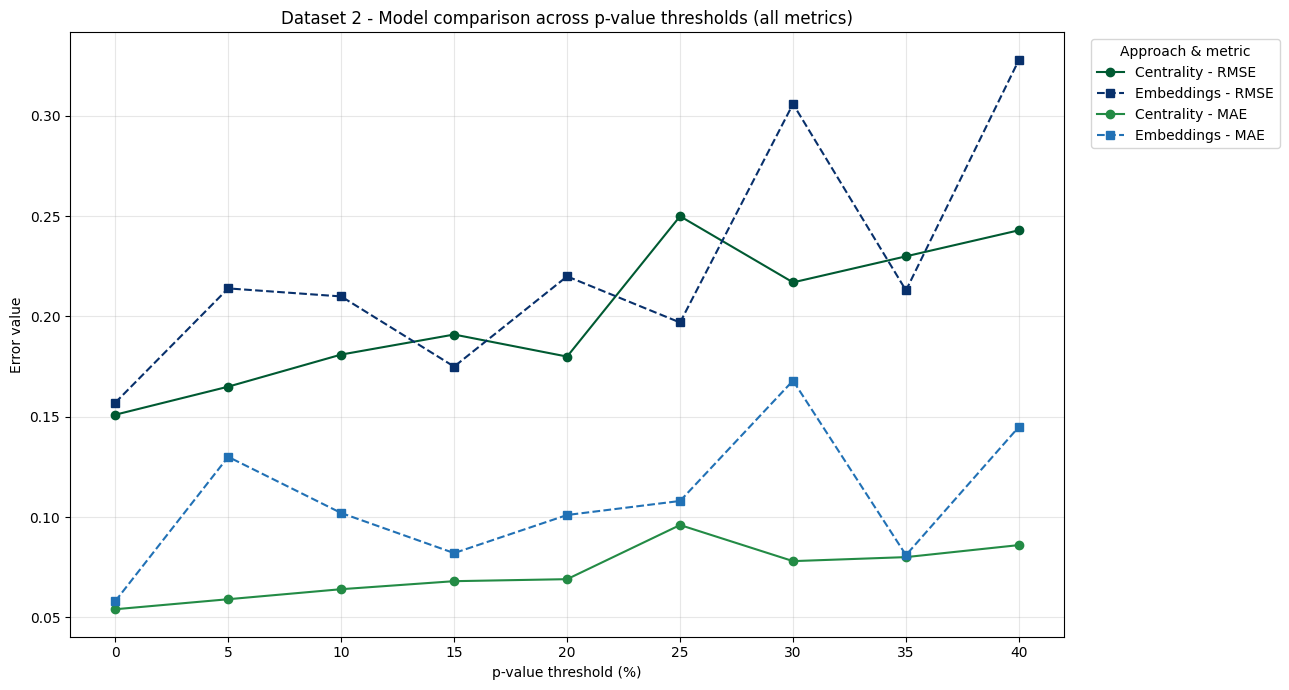

Saved figure: C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\predictions\07_p_value_comparison\dataset2_lines_all_metrics.png


In [16]:
plot_grouped_bar_metrics(
    comparison,
    dataset_group='dataset2',
    title='Dataset 2 - Model comparison across p-value thresholds (grouped bins)',
    output_filename='dataset2_grouped_bins_all_metrics.png',
)

plot_all_metric_lines(
    comparison,
    dataset_group='dataset2',
    title='Dataset 2 - Model comparison across p-value thresholds (all metrics)',
    output_filename='dataset2_lines_all_metrics.png',
)